N=20
  mu_MLE (grid)     = 2.6411
  1σ width (like)   = 0.4324   from ΔlnL=0.5
  1σ width (theory) = 0.4472 = sigma/sqrt(N)

N=100
  mu_MLE (grid)     = 1.5841
  1σ width (like)   = 0.1922   from ΔlnL=0.5
  1σ width (theory) = 0.2000 = sigma/sqrt(N)

N=1000
  mu_MLE (grid)     = 1.3919
  1σ width (like)   = 0.0480   from ΔlnL=0.5
  1σ width (theory) = 0.0632 = sigma/sqrt(N)



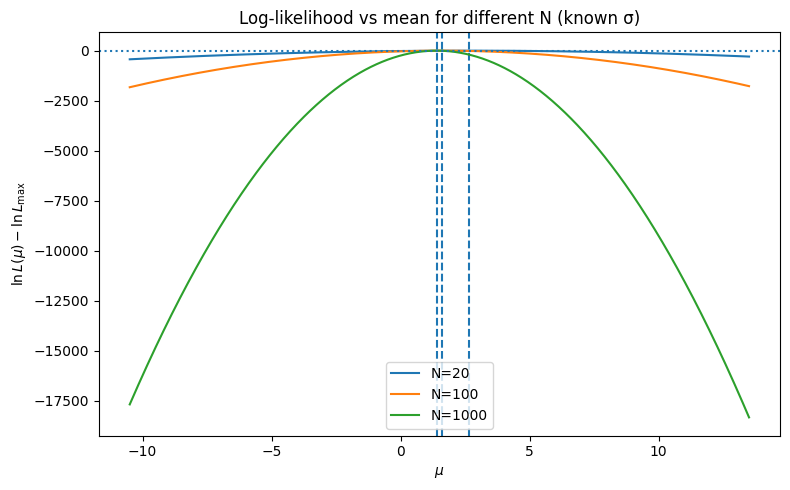

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

mu_true = 1.5
sigma = 2.0
Ns = [20, 100, 1000]
mu_grid = np.linspace(mu_true - 6*sigma, mu_true + 6*sigma, 1000)

def logL_mu(x, mu_grid, sigma):
    N = len(x)
    return -N*np.log(sigma*np.sqrt(2*np.pi)) - np.sum((x[:,None] - mu_grid[None,:])**2, axis=0)/(2*sigma**2)

plt.figure(figsize=(8,5))

for N in Ns:
    x = np.random.normal(mu_true, sigma, N)

    ll = logL_mu(x, mu_grid, sigma)
    ll -= ll.max()                   # shift so max is 0
    mu_mle = mu_grid[np.argmax(ll)]  # MLE from grid

    # analysis: estimate 1σ width using ΔlnL = 0.5 rule
    mask = ll >= -0.5
    mu_left = mu_grid[mask][0]
    mu_right = mu_grid[mask][-1]
    sigma_mu_like = 0.5*(mu_right - mu_left)

    # theory for known sigma: sigma_mu = sigma/sqrt(N)
    sigma_mu_theory = sigma/np.sqrt(N)

    print(f"N={N}")
    print(f"  mu_MLE (grid)     = {mu_mle:.4f}")
    print(f"  1σ width (like)   = {sigma_mu_like:.4f}   from ΔlnL=0.5")
    print(f"  1σ width (theory) = {sigma_mu_theory:.4f} = sigma/sqrt(N)\n")

    plt.plot(mu_grid, ll, label=f"N={N}")
    plt.axvline(mu_mle, linestyle="--")

plt.axhline(-0.5, linestyle=":")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\ln L(\mu) - \ln L_{\max}$")
plt.title("Log-likelihood vs mean for different N (known σ)")
plt.legend()
plt.tight_layout()
plt.show()

# print(r"Conclusion: parameter uncertainty scales as $\sigma_\mu=\sigma/\sqrt{N}$, so the likelihood peak narrows like $1/\sqrt{N}$.")


Conclusion: parameter uncertainty scales as $\sigma_\mu=\sigma/\sqrt{N}$, so the likelihood peak narrows like $1/\sqrt{N}$.
